In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========= 1. 读数据 =========
df_region = pd.read_csv("../../CSV/IAMC/Region_yield_filtered.csv")
df_basin  = pd.read_csv("../../CSV/IAMC/Basin_yield_17regions.csv")

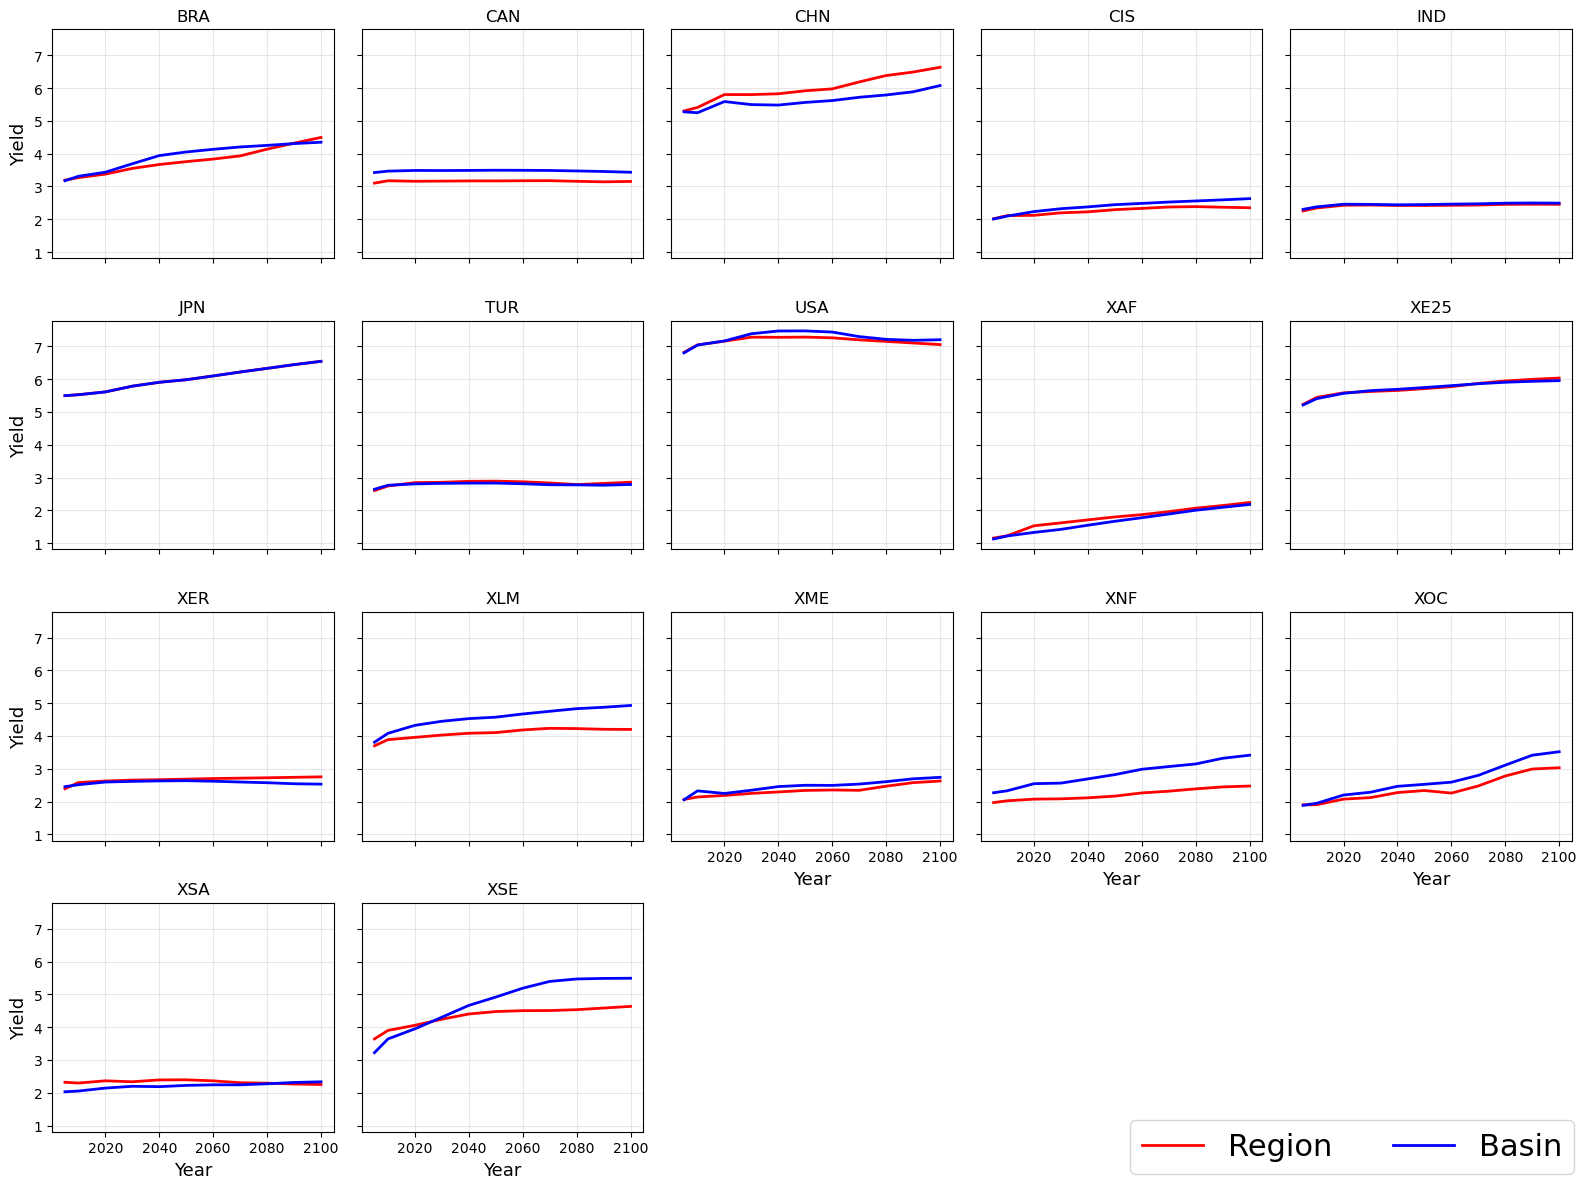

In [2]:
# ========= 2. 只取 CEREAL =========
df_region = df_region[df_region["land"] == "CEREAL"].copy()

# 统一列名
df_region = df_region.rename(columns={
    "region": "17region",
    "Value": "region"
})

df_basin = df_basin.rename(columns={
    "yield_region": "basin"
})

# ========= 3. 合并 =========
df = pd.merge(
    df_region[["17region", "year", "region"]],
    df_basin[["17region", "year", "basin"]],
    on=["17region", "year"],
    how="inner"
)

# ========= 4. 17 个 region =========
regions = sorted(df["17region"].unique())

# ========= 5. 画图 =========
n = len(regions)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, reg in enumerate(regions):
    ax = axes[i]
    d = df[df["17region"] == reg]

    ax.plot(d["year"], d["region"], label="Region", linewidth=2,color="red",)
    ax.plot(d["year"], d["basin"],  label="Basin",  linewidth=2, color="blue",)
    ax.set_title(reg)
    ax.grid(alpha=0.3)

    # ---------- 行列位置 ----------
    row = i // ncols
    col = i % ncols

    # 左侧一列：显示 y 轴
    if col == 0:
        ax.set_ylabel("Yield",fontsize=13)
        ax.tick_params(axis="y", labelleft=True)
    else:
        ax.tick_params(axis="y", labelleft=False)

    # 底部一行：显示 x 轴
    if row == nrows - 1:
        ax.set_xlabel("Year",fontsize=13)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    if i >= n - 5:
        ax.set_xlabel("Year",fontsize=13)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)
handles, labels = axes[0].get_legend_handles_labels()
    
fig.legend(
        handles, labels,
        loc="lower right",
        ncol=2,
        fontsize=22
    )

# 删除多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../../plot/yield/yield_diff_17r.png")
plt.show()
